<a href="https://colab.research.google.com/github/ravindul97/YOLO-Detection-Model-Codes/blob/pt_model_testing/Testing_pt_model_working_properly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading .pt model and inferecing for an image


image 1/1 /content/test2.jpg: 320x640 3 busfaces, 2 busnumbers, 8.8ms
Speed: 1.7ms preprocess, 8.8ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict2
1 label saved to /content/runs/detect/predict2/labels
=== Detections ===
01  class=0 (busface)  conf=0.929  xyxy=(343.3,191.8,784.9,691.6)
02  class=0 (busface)  conf=0.908  xyxy=(793.8,203.5,1370.9,749.7)
03  class=0 (busface)  conf=0.857  xyxy=(1179.7,124.0,1492.2,630.3)
04  class=1 (busnumber)  conf=0.842  xyxy=(623.9,297.6,708.4,356.8)
05  class=1 (busnumber)  conf=0.821  xyxy=(1119.2,257.5,1197.5,324.6)

Saved to folder: /content/runs/detect/predict2


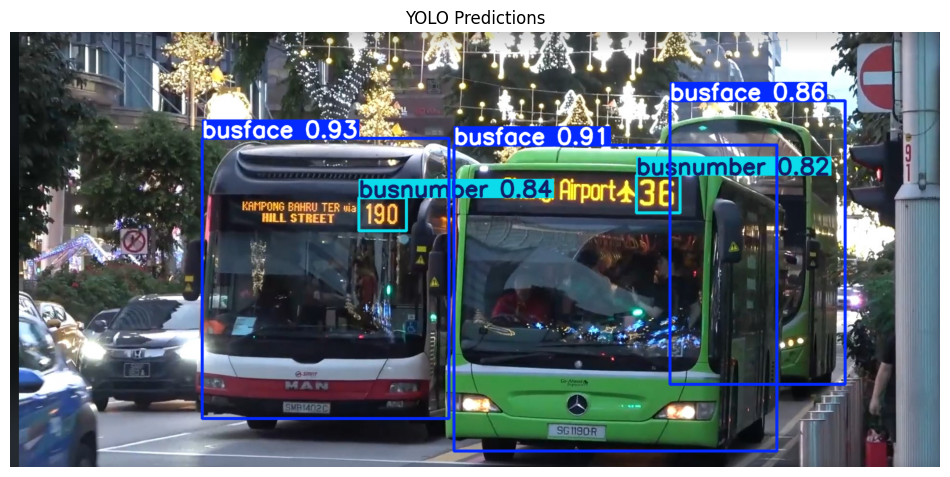

In [ ]:
# Colab YOLO11n (.pt) single-image inference + inline display

!pip -q install -U ultralytics opencv-python

import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# ----------------------------
# 1) Set paths (EDIT THESE)
# ----------------------------
WEIGHTS = "/content/best.pt"   # <-- your trained .pt
IMAGE   = "/content/test2.jpg"                           # <-- your input image

CONF = 0.25
IOU  = 0.7
IMGSZ = 640
DEVICE = 0  # 0 for GPU, "cpu" for CPU

# ----------------------------
# 2) Load model and predict
# ----------------------------
model = YOLO(WEIGHTS)

results = model.predict(
    source=IMAGE,
    conf=CONF,
    iou=IOU,
    imgsz=IMGSZ,
    device=DEVICE,
    save=True,        # saves annotated image
    save_txt=True,    # saves labels
    save_conf=True
)

r = results[0]
names = model.names

# ----------------------------
# 3) Print detections
# ----------------------------
print("=== Detections ===")
if r.boxes is None or len(r.boxes) == 0:
    print("No detections found.")
else:
    for i, b in enumerate(r.boxes):
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = [float(v) for v in b.xyxy[0].tolist()]
        print(f"{i+1:02d}  class={cls_id} ({names.get(cls_id, str(cls_id))})  conf={conf:.3f}  "
              f"xyxy=({x1:.1f},{y1:.1f},{x2:.1f},{y2:.1f})")

print("\nSaved to folder:", r.save_dir)

# ----------------------------
# 4) Display annotated image inline
# ----------------------------
# r.plot() returns an annotated image in BGR (OpenCV format)
annotated_bgr = r.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("YOLO Predictions")
plt.show()


# Loading .pt model and inferecing for a video

In [ ]:
!pip -q install -U ultralytics opencv-python

import cv2
from ultralytics import YOLO

WEIGHTS = "/content/best.pt"
VIDEO   = "/content/MP4_1766259832786.mp4"
OUT_MP4 = "/content/output_annotated3.mp4"

CONF   = 0.25
IOU    = 0.7
IMGSZ  = 640
DEVICE = 0  # or "cpu"

model = YOLO(WEIGHTS)

cap = cv2.VideoCapture(VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUT_MP4, fourcc, fps, (w, h))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Predict on this frame
    r = model.predict(
        source=frame,
        conf=CONF,
        iou=IOU,
        imgsz=IMGSZ,
        device=DEVICE,
        verbose=False
    )[0]

    # r.plot() returns annotated frame in BGR
    annotated = r.plot()
    writer.write(annotated)

    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"Processed {frame_idx} frames...")

cap.release()
writer.release()
print("Done! Saved:", OUT_MP4)


Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
Processed 500 frames...
Processed 550 frames...
Processed 600 frames...
Processed 650 frames...
Processed 700 frames...
Processed 750 frames...
Processed 800 frames...
Processed 850 frames...
Processed 900 frames...
Processed 950 frames...
Processed 1000 frames...
Processed 1050 frames...
Done! Saved: /content/output_annotated3.mp4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil, os

src = "/content/output_annotated3.mp4"  # <-- your mp4 path in colab
dst = "/content/drive/MyDrive/colab_exports/output3.mp4"  # <-- where you want it in Drive

os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copy2(src, dst)

print("Saved to:", dst)


Saved to: /content/drive/MyDrive/colab_exports/output3.mp4
